In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import glob as glob
from matplotlib.ticker import LogLocator, FuncFormatter
from matplotlib.ticker import MaxNLocator
from matplotlib.patches import Patch
import matplotlib as mpl

from scipy.stats import mannwhitneyu

In [2]:
# Read in the files from the first classifier which was produced in early 2025
files = glob.glob('../data/2026_06_17_for_upload/*.csv')

In [3]:
files

['../data/2026_06_17_for_upload/P01_Day_0_image_1.csv',
 '../data/2026_06_17_for_upload/P18_Prog_image_1.csv',
 '../data/2026_06_17_for_upload/P04_Day_0_image_1.csv',
 '../data/2026_06_17_for_upload/P01_Day_0_image_2.csv',
 '../data/2026_06_17_for_upload/P04_Day_168_image_1.csv',
 '../data/2026_06_17_for_upload/P18_Day_0_image_1.csv',
 '../data/2026_06_17_for_upload/P03_Day_168_image_1.csv',
 '../data/2026_06_17_for_upload/P28_Day_0_image_1.csv',
 '../data/2026_06_17_for_upload/P08_Day_140_image_1.csv',
 '../data/2026_06_17_for_upload/P19_Day_0_image_2.csv',
 '../data/2026_06_17_for_upload/P05_Day_0_image_1.csv',
 '../data/2026_06_17_for_upload/P18_Day_168_image_1.csv',
 '../data/2026_06_17_for_upload/P19_Day_0_image_1.csv',
 '../data/2026_06_17_for_upload/P03_Day_0_image_1.csv',
 '../data/2026_06_17_for_upload/P17_Day_168_image_1.csv',
 '../data/2026_06_17_for_upload/P02_Day_0_image_1.csv',
 '../data/2026_06_17_for_upload/P08_Day_168_image_1.csv',
 '../data/2026_06_17_for_upload/P07_D

In [7]:
# Read in each file from the first classifier and extract the number of each cell type
cell_type_dict = {}
for i in files:
    z = i.replace('../data/2026_06_17_for_upload/', '').replace('.csv', '')
    a = pd.read_csv(i)
    b = a['2025_10_13_HH'].value_counts()
    b = dict(b)
    b['Total'] = a.shape[0]
    cell_type_dict[z] = b


In [8]:
# Turn the dictionary into a dataframe and calculate the percentage of each cell
cell_type_df = pd.DataFrame(cell_type_dict)
cell_type_df = cell_type_df.T
cell_type_df['patient'] = cell_type_df.index.str.split('_').str[0]
cell_type_df['tp'] = cell_type_df.index.str.split('_').str[1:3].str.join('_')
cell_type_df['tp'] = cell_type_df['tp'].str.replace('_image', '')
cell_type_df['tp'] = cell_type_df['tp'].str.replace('_image', '')
cell_type_df = cell_type_df.groupby(['patient', 'tp']).sum()
cell_type_df = cell_type_df.reset_index()

cell_type_df.loc[:, 'Neg':'Stromal'] = cell_type_df.loc[:, 'Neg':'Stromal'].div(cell_type_df['Total'], axis=0) * 100
cell_type_df.head()

/var/folders/8n/0q8k5j814xj4bcjqhcvny6p80000gn/T/ipykernel_94461/2682625034.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[74.26068463 75.15976258 84.08710218 69.44228935 70.04124884 66.51343962
 42.49156209 75.67054381 19.60498693 77.92238035 85.77956989 80.54196595
 74.87846482 81.15884649 68.82477129 72.96224687 72.27710121 68.62281932
 67.80675982 55.04953871 79.96171027 76.71386829 76.30695501 70.1165538
 89.93046613 72.72051559 82.32490272 56.44504062 79.51018551 59.94021725
 71.61521502 77.24340514 67.63556232 42.63795463 60.16137166]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  cell_type_df.loc[:, 'Neg':'Stromal'] = cell_type_df.loc[:, 'Neg':'Stromal'].div(cell_type_df['Total'], axis=0) * 100
/var/folders/8n/0q8k5j814xj4bcjqhcvny6p80000gn/T/ipykernel_94461/2682625034.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise i

,patient,tp,Neg,CD8_T,CD4_T,Endothelial,HSPC,Stromal,Total
0,P01,Day_0,74.260685,12.274661,7.089326,2.253393,3.195260,0.926676,19748
1,P01,Day_336,75.159763,4.153827,2.682357,1.797200,6.676938,9.529915,96706
2,P02,Day_0,84.087102,2.847571,10.385260,0.670017,1.340034,0.670017,597
3,P03,Day_0,69.442289,10.940541,13.224801,1.565660,2.509380,2.317329,78625
4,P03,Day_168,70.041249,5.781950,16.894246,1.219686,4.846739,1.216130,28122


In [9]:
cell_type_df['pid_tp'] = cell_type_df['patient'] + '_' + cell_type_df['tp']

In [10]:
for i in cell_type_df['pid_tp'].unique():
    
    print(f"'{i}',")

'P01_Day_0',
'P01_Day_336',
'P02_Day_0',
'P03_Day_0',
'P03_Day_168',
'P03_Day_336',
'P04_Day_0',
'P04_Day_168',
'P04_Day_336',
'P05_Day_0',
'P05_Day_336',
'P07_Day_0',
'P07_Day_336',
'P08_Day_0',
'P08_Day_140',
'P08_Day_168',
'P11_Day_0',
'P11_Day_336',
'P12_Day_336',
'P13_Day_0',
'P14_Day_0',
'P14_Prog',
'P16_Day_0',
'P17_Day_0',
'P17_Day_168',
'P18_Day_0',
'P18_Day_168',
'P18_Prog',
'P19_Day_0',
'P21_Day_0',
'P22_Day_0',
'P24_Day_0',
'P25_Day_0',
'P25_Day_168',
'P28_Day_0',


In [15]:
# Create dictionaries which detail the clinical outcome
outcomes = pd.read_excel('../data/Outcomes_master_simplified_updatedJan24_patient_updated.xlsx')
outcomes[['Outcome_C6_revised_Vid', 'Outcome_C12_CC486']] = outcomes[['Outcome_C6_revised_Vid', 'Outcome_C12_CC486']].replace({
        'non-responder_2': 'Non-responder',
        'responder_1': 'Responder'
    })

outcomes_6 = dict(zip(outcomes['PID'], outcomes['Outcome_C6_revised_Vid']))
outcomes_12 = dict(zip(outcomes['PID'], outcomes['Outcome_C12_CC486']))
diagnosis = dict(zip(outcomes['PID'], outcomes['Diagnosis']))
outcomes_6

{'P08': 'Non-responder',
 'P24': 'Non-responder',
 'P19': 'Responder',
 'P37': nan,
 'P36': nan,
 'P39': 'Non-responder',
 'P12': 'Responder',
 'P04': 'Responder',
 'P33': nan,
 'P03': 'Responder',
 'P27': 'Non-responder',
 'P09': 'Non-responder',
 'P38': 'Non-responder',
 'P30': nan,
 'P40': nan,
 'P06': 'Responder',
 'P10': 'Responder',
 'P16': 'Non-responder',
 'P34': nan,
 'P14': 'Responder',
 'P05': 'Responder',
 'P02': 'Non-responder',
 'P01': 'Responder',
 'P11': 'Responder',
 'P28': 'Non-responder',
 'P07': 'Non-responder',
 'P31': nan,
 'P15': 'Responder',
 'P20': 'Responder',
 'P26': nan,
 'P32': nan,
 'P17': 'Responder',
 'P18': 'Responder',
 'P22': 'Non-responder',
 'P29': nan,
 'P35': nan,
 'P25': 'Non-responder',
 'P23': nan,
 'P13': 'Responder',
 'P21': 'Responder'}

In [17]:
# Delete the following sample as the alignment was crappy. (i.e many T cells didn't have a nucleus)

cell_type_df1 = cell_type_df.copy()
print(cell_type_df1.shape)

to_del = ['P17_Day_168',  'P02_Day_0',  'P18_Prog',  'P04_Day_336', 'P08_Day_140'] # Create a list of samples and timepoints to remove
cell_type_df1 = cell_type_df1.loc[~cell_type_df1['pid_tp'].isin(to_del), :]

print(cell_type_df1.shape)

(35, 10)
(30, 10)


In [19]:
cell_type_df1

,patient,tp,Neg,CD8_T,CD4_T,Endothelial,HSPC,Stromal,Total,pid_tp
0,P01,Day_0,74.260685,12.274661,7.089326,2.253393,3.195260,0.926676,19748,P01_Day_0
1,P01,Day_336,75.159763,4.153827,2.682357,1.797200,6.676938,9.529915,96706,P01_Day_336
3,P03,Day_0,69.442289,10.940541,13.224801,1.565660,2.509380,2.317329,78625,P03_Day_0
4,P03,Day_168,70.041249,5.781950,16.894246,1.219686,4.846739,1.216130,28122,P03_Day_168
5,P03,Day_336,66.513440,4.588343,18.020710,0.952024,5.210123,4.715361,82666,P03_Day_336
6,P04,Day_0,42.491562,3.522285,5.818260,0.897447,41.995673,5.274773,115550,P04_Day_0
7,P04,Day_168,75.670544,4.680786,6.385357,0.872358,4.525628,7.865327,92164,P04_Day_168
9,P05,Day_0,77.922380,5.893311,2.770687,2.329556,6.137603,4.946462,227597,P05_Day_0
10,P05,Day_336,85.779570,2.876344,0.940860,0.779570,8.279570,1.344086,3720,P05_Day_336
11,P07,Day_0,80.541966,3.744663,2.145429,0.959658,12.494934,0.113350,170269,P07_Day_0


CD8_T 48.0 0.42515082956259426
CD4_T 49.0 0.37493715434891906
HSPC 27.0 0.3283056812468577
Stromal 58.0 0.08534439416792358
Endothelial 46.0 0.5360105580693816


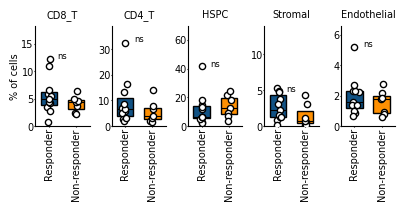

In [25]:
cell_type_df2 = cell_type_df1.loc[cell_type_df1['tp'] == 'Day_0', :].copy()


# Make the text editable in illustrator
mpl.rcParams['pdf.fonttype'] = 42
cell_type_df2['outcome'] = cell_type_df2['patient'].map(outcomes_6)

to_plot = ['CD8_T', 'CD4_T', 'HSPC', 'Stromal', 'Endothelial']

# Create a dictionary which specifies the y-axis limit 
max_dict = {'CD8_T': 16.581953642384107,
           'CD4_T': 35.48453388134191,
           'Stromal': 12.654484954943378,
           'HSPC': 63.34861402681976,
           'Endothelial': 6} 
max_dict = {k: v * 1.1 for k, v in max_dict.items()}


# Specify the order of groups
group_order = ['Responder', 'Non-responder']
color_dict = {'Responder': '#115284', 'Non-responder': '#fe9003'}

# Group by outcome and calculate means
grouped = cell_type_df2.groupby('outcome')[to_plot].mean().reindex(group_order)


fig, ax = plt.subplots(ncols=len(to_plot), figsize=(4.1875, 1.5))

x = np.arange(len(grouped))
width = 0.9

for num, cell_type in enumerate(to_plot):
    # Calculate statistics
    responder = cell_type_df2.loc[cell_type_df2['outcome'] == 'Responder', cell_type]
    non_responder = cell_type_df2.loc[cell_type_df2['outcome'] == 'Non-responder', cell_type]
    stat, p_value = mannwhitneyu(responder, non_responder, alternative='two-sided')
    print(cell_type, stat, p_value)
    
    # Draw box plots
    data_to_plot = [cell_type_df2.loc[cell_type_df2['outcome'] == group, cell_type] for group in group_order]
    bp = ax[num].boxplot(data_to_plot, positions=range(len(group_order)), widths=0.6,
                         patch_artist=True, showfliers=False)
    for patch, group in zip(bp['boxes'], group_order):
        patch.set_facecolor(color_dict[group])
        patch.set_alpha(1.0)
    for element in ['whiskers', 'caps']:
        for item in bp[element]:
            item.set_linewidth(0)
    for item in bp['medians']:
        item.set_color('black')
        item.set_linewidth(0.8)

    
    
    # Add individual points
    for i, group in enumerate(group_order):
        # Get individual values for this group
        group_data = cell_type_df2.loc[cell_type_df2['outcome'] == group, cell_type]
        
        # Add scatter points with jitter for visibility
        jitter = np.random.normal(0, 0.05, size=len(group_data))
        ax[num].scatter(np.repeat(i, len(group_data)) + jitter, 
                       group_data, 
                       color='white', edgecolor='black', 
                       s=20, 
                       alpha=1.0,
                       zorder=3)

    # Add p-value text to plot
    y_max = ax[num].get_ylim()[1]
    if p_value < 0.001:
        p_text = '***'
    elif p_value < 0.01:
        p_text = '**'
    else:
        p_text = 'ns'
    
    ax[num].text(0.5, y_max * 1.05, p_text, 
                ha='center', va='top', fontsize=6)
    
    ax[num].set_title(cell_type, fontsize = 7)
    ax[num].set_xticks(x)
    ax[num].set_xticklabels(group_order, rotation=90, fontsize=7)
    ax[num].set_ylabel('Value' if num == 0 else '')
    ax[num].tick_params(length=1, pad=0, labelsize=7)
    ax[num].spines[['top', 'right']].set_visible(False)
    ax[num].set_ylim(bottom = 0, top = max_dict[cell_type])
    if num == 0:
        ax[num].set_ylabel('% of cells', fontsize=7, labelpad=1)
    else:
        ax[num].set_ylabel('')

#plt.tight_layout(w_pad=0.4)
plt.subplots_adjust(left=0.12, right=0.98, top=0.92, bottom=0.25, wspace=0.4)
plt.savefig('../results/percent_of_cells_at_diagnosis_by_c7.pdf', dpi=600, bbox_inches='tight')
plt.show()

In [27]:
# Delete some spare samples where alignment was crappy or cell number was small
cell_type_df1 = cell_type_df.copy()
print(cell_type_df1.shape)

to_del = ['P17_Day_168',  'P02_Day_0', 'P08_Day_140'] # Create a list of samples and timepoints to remove
cell_type_df1 = cell_type_df1.loc[~cell_type_df1['pid_tp'].isin(to_del), :]

(35, 10)


CD8_T 38.0 0.08125208125208126
CD4_T 46.0 0.002664002664002664
HSPC 0.0 0.000666000666000666
Stromal 22.0 0.8518148518148518
Endothelial 28.0 0.662004662004662


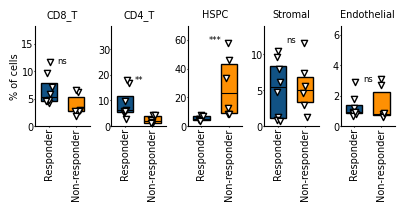

In [29]:
# Make a graph which measures the cell type abundance when a clinical response was measure

# Specify the font to be editable in illustrator
mpl.rcParams['pdf.fonttype'] = 42

cell_type_df2 = cell_type_df1.loc[cell_type_df1['tp'] != 'Day_0', :].copy() # Make sure I'm excluding the diagnosis samples

# Add specific outcomes to each row of the df # A complex for loop is required as i'm combining multiple timepoints
outcome = []
for x, y in zip(cell_type_df2['patient'], cell_type_df2['tp']):
    if y == 'Day_336':
        outcome.append(outcomes_12[x])
    elif y == 'Day_168':
        outcome.append(outcomes_6[x])
    elif y == 'Prog':
        outcome.append('Non-responder')

cell_type_df2['outcome'] = outcome  # Add the clinical outcome for each sample

# Create a dictionary which specifies the y-axis limit for each cell type
max_dict = {'CD8_T': 16.581953642384107,
           'CD4_T': 35.48453388134191,
           'Stromal': 12.654484954943378,
           'HSPC': 63.34861402681976, 
           'Endothelial': 6} 
max_dict = {k: v * 1.1 for k, v in max_dict.items()}


# Specify the order of groups
group_order = ['Responder', 'Non-responder']
color_dict = {'Responder': '#115284', 'Non-responder': '#fe9003'}

# Group by outcome and calculate means
to_plot = ['CD8_T', 'CD4_T', 'HSPC', 'Stromal', 'Endothelial']
grouped = cell_type_df2.groupby('outcome')[to_plot].mean().reindex(group_order)


fig, ax = plt.subplots(ncols=len(to_plot), figsize=(4.185, 1.5))

x = np.arange(len(grouped))
width = 0.9

# Make the graphs
for num, cell_type in enumerate(to_plot):
    # Calculate statistics
    responder = cell_type_df2.loc[cell_type_df2['outcome'] == 'Responder', cell_type]
    non_responder = cell_type_df2.loc[cell_type_df2['outcome'] == 'Non-responder', cell_type]
    stat, p_value = mannwhitneyu(responder, non_responder, alternative='two-sided')
    print(cell_type, stat, p_value)
    
    # Draw box plots
    data_to_plot = [cell_type_df2.loc[cell_type_df2['outcome'] == group, cell_type] for group in group_order]
    bp = ax[num].boxplot(data_to_plot, positions=range(len(group_order)), widths=0.6,
                         patch_artist=True, showfliers=False)
    for patch, group in zip(bp['boxes'], group_order):
        patch.set_facecolor(color_dict[group])
        patch.set_alpha(1.0)
    for element in ['whiskers', 'caps']:
        for item in bp[element]:
            item.set_linewidth(0)
    for item in bp['medians']:
        item.set_color('black')
        item.set_linewidth(0.8)
    
    # Add individual points
    for i, group in enumerate(group_order):
        # Get individual values for this group
        group_data = cell_type_df2.loc[cell_type_df2['outcome'] == group, cell_type]
        
        # Add scatter points with jitter for visibility
        jitter = np.random.normal(0, 0.05, size=len(group_data))
        ax[num].scatter(np.repeat(i, len(group_data)) + jitter, 
                       group_data, 
                       color='white', edgecolor='black', 
                       s=20, marker = 'v',
                       alpha=1.0,
                       zorder=3)
    
    # Add p-value text to plot
    y_max = ax[num].get_ylim()[1]
    if p_value < 0.001:
        p_text = '***'
    elif p_value < 0.01:
        p_text = '**'
    else:
        p_text = 'ns'
    
    ax[num].text(0.5, y_max * 1.05, p_text, 
                ha='center', va='top', fontsize=6)
    
    ax[num].set_title(cell_type, fontsize=7)
    ax[num].set_xticks(x)
    ax[num].set_xticklabels(group_order, rotation=90, fontsize=7)
    ax[num].tick_params(length=1, pad=0, labelsize=7)
    ax[num].spines[['top', 'right']].set_visible(False)
    
    ax[num].set_ylim(bottom = 0, top = max_dict[cell_type])
    if num == 0:
        ax[num].set_ylabel('% of cells', fontsize=7, labelpad=1)
    else:
        ax[num].set_ylabel('')

#plt.tight_layout(w_pad=0.4)
plt.subplots_adjust(left=0.12, right=0.98, top=0.92, bottom=0.25, wspace=0.4)
plt.savefig('../results/percent_of_cells_at_response.pdf', dpi=600, bbox_inches='tight')
plt.show()